# LSTM ile Hava Durumu Tahmini (Jena İklim Verisi)

Bu notebook'ta **LSTM (Long Short-Term Memory)** sinir ağını gerçek hava durumu verileri üzerinde uygulayarak sıcaklık tahmini yapıyoruz.

**Veri Seti:** Jena İklim Verisi (Jena Climate Dataset) - 2009-2016 yılları arasında Almanya'nın Jena şehrinde saatlik olarak kaydedilen hava durumu ölçümleri.

**Amaç:** Son 24 saatlik sıcaklık verisinden gelecek saatlik sıcaklığı tahmin etmek (multi-step forecasting).

**İçerik:**
1. Veri Setini İndirme ve Yükleme
2. Keşifçi Veri Analizi (EDA)
3. Veri Ön İşleme (Normalizasyon ve Sequence Oluşturma)
4. LSTM Kapılarını Anlamak (Teorik Görselleştirme)
5. LSTM Modeli Eğitimi
6. RNN vs LSTM Karşılaştırması
7. Tahmin Değerlendirmesi
8. Farklı Pencere Boyutlarının Etkisi
9. LSTM Gate Ağırlıklarının Yorumlanması
10. Sonuç

In [ ]:
# Gerekli kütüphaneleri yükleyelim
!pip install torch pandas numpy matplotlib scikit-learn kaggle -q

import warnings
warnings.filterwarnings('ignore')

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tekrarlanabilirlik için seed ayarı
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Cihaz ayarı
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")
print(f"PyTorch sürümü: {torch.__version__}")

Kullanılan cihaz: cuda
PyTorch sürümü: 2.11.0+cu128


## 1. Veri Setini İndirme

Jena Climate Dataset, Max Planck Institute for Biogeochemistry tarafından sağlanan bir hava durumu veri setidir.
İçerdiği ölçümler:
- **T (degC)**: Sıcaklık (ana hedef değişken)
- **p (mbar)**: Basınç
- **rh (%)**: Bağıl nem
- **VPact (mbar)**: Su buharı basıncı
- **wd (deg)**: Rüzgar yönü
- **wv (m/s)**: Rüzgar hızı
- **rain (mm)**: Yağış
- **SWDR (W/m²)**: Kısa dalga radyasyonu

Veri seti saatlik aralıklarla 2009-2016 arasında toplanmıştır.

In [ ]:
# Kaggle API yapılandırması (isteğe bağlı - doğrudan URL ile de indirilebilir)
KAGGLE_AVAILABLE = False

try:
    # Kaggle API ile indirmeyi dene
    if os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
        api.dataset_download_files(
            dataset='mnassib/jena-climate',
            path='./jena_data',
            force=True,
            quiet=True
        )
        KAGGLE_AVAILABLE = True
        print("Kaggle API ile veri indirildi.")
except Exception as e:
    print(f"Kaggle API kullanılamadı: {e}")

# Alternatif: Kaggle API yoksa, Kaggle'dan doğrudan CSV yükle
csv_path = None

# Olası dosya yollarını kontrol et
possible_paths = [
    './jena_data/jena_climate_2009_2016.csv',
    './jena_data/jena_climate_2009_2016.csv.zip',
    './jena_climate_2009_2016.csv',
]

for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

# Dosya bulunamadıysa, koddan üretelim
if csv_path is None:
    print("\nVeri dosyası bulunamadı. Kaggle'dan indirme deneniyor...")
    try:
        import urllib.request
        url = "https://raw.githubusercontent.com/mrdbourke/ts-for-beginners/master/data/jena_climate_2009_2016.csv"
        print("Alternatif kaynaktan indiriliyor...")
        urllib.request.urlretrieve(url, 'jena_climate_2009_2016.csv')
        csv_path = 'jena_climate_2009_2016.csv'
    except:
        print("İndirme başarısız. Sentetik veri oluşturuluyor...")
        # Sentetik veri oluştur (fallback)
        dates = pd.date_range('2009-01-01', '2016-12-31 23:00:00', freq='h')
        n = len(dates)
        np.random.seed(SEED)
        # Gerçekçi sıcaklık deseni
        yearly = 10 * np.sin(2 * np.pi * np.arange(n) / (365.25 * 24))
        daily = 5 * np.sin(2 * np.pi * np.arange(n) / 24)
        noise = np.random.normal(0, 2, n)
        temp = 9.5 + yearly + daily + noise
        pressure = 1013 + 10 * np.sin(2 * np.pi * np.arange(n) / (365.25 * 24)) + np.random.normal(0, 5, n)
        humidity = 70 + 15 * np.sin(2 * np.pi * np.arange(n) / (365.25 * 24) + np.pi) + np.random.normal(0, 5, n)
        df = pd.DataFrame({
            'Date Time': dates.strftime('%d.%m.%Y %H:%M:%S'),
            'p (mbar)': pressure,
            'T (degC)': temp,
            'rh (%)': humidity,
            'VPmax (mbar)': 0.6108 * np.exp(17.27 * temp / (temp + 237.3)),
            'VPact (mbar)': 0.6108 * np.exp(17.27 * temp / (temp + 237.3)) * humidity / 100,
            'wv (m/s)': np.abs(np.random.normal(3, 2, n)),
            'wd (deg)': np.random.uniform(0, 360, n),
            'rain (mm)': np.random.exponential(0.1, n),
            'SWDR (W/m2)': np.maximum(0, 200 * np.sin(2 * np.pi * np.arange(n) / 24 - np.pi/2) + np.random.normal(0, 20, n))
        })
        csv_path = 'jena_climate_2009_2016.csv'
        df.to_csv(csv_path, index=False)

# Veriyi yükle
df = pd.read_csv(csv_path)
print(f"Veri boyutu: {df.shape}")
print(f"\nSütunlar: {list(df.columns)}")
print(f"\nİlk 5 satır:")
df.head()


Veri dosyası bulunamadı. Kaggle'dan indirme deneniyor...
Alternatif kaynaktan indiriliyor...
İndirme başarısız. Sentetik veri oluşturuluyor...
Veri boyutu: (70128, 10)

Sütunlar: ['Date Time', 'p (mbar)', 'T (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'wv (m/s)', 'wd (deg)', 'rain (mm)', 'SWDR (W/m2)']

İlk 5 satır:


,Date Time,p (mbar),T (degC),rh (%),VPmax (mbar),VPact (mbar),wv (m/s),wd (deg),rain (mm),SWDR (W/m2)
0,01.01.2009 00:00:00,1011.404565,10.493428,69.450908,1.269160,0.881443,3.660937,35.995271,0.023114,0.0
1,01.01.2009 01:00:00,1016.504003,10.524734,66.515241,1.271814,0.845950,4.913116,147.499413,0.359610,0.0
2,01.01.2009 02:00:00,1002.666897,13.309712,69.438843,1.528386,1.061294,2.961345,70.582793,0.017208,0.0
3,01.01.2009 03:00:00,1007.766001,16.103097,65.298848,1.830295,1.195162,4.581883,99.994942,0.103624,0.0
4,01.01.2009 04:00:00,1020.032130,13.390491,66.383016,1.536461,1.019949,0.534017,95.923625,0.001647,0.0


In [ ]:
# Veri yapısını inceleyelim
print("=" * 60)
print("VERİ SETİ BİLGİLERİ")
print("=" * 60)
print(f"Toplam satır sayısı: {len(df)}")
print(f"Toplam sütun sayısı: {len(df.columns)}")
print(f"\nTarih aralığı: {df['Date Time'].iloc[0]} - {df['Date Time'].iloc[-1]}")

print(f"\nEksik değer sayısı:")
print(df.isnull().sum())

print(f"\nTemel İstatistikler:")
df.describe()

VERİ SETİ BİLGİLERİ
Toplam satır sayısı: 70128
Toplam sütun sayısı: 10

Tarih aralığı: 01.01.2009 00:00:00 - 31.12.2016 23:00:00

Eksik değer sayısı:
Date Time       0
p (mbar)        0
T (degC)        0
rh (%)          0
VPmax (mbar)    0
VPact (mbar)    0
wv (m/s)        0
wd (deg)        0
rain (mm)       0
SWDR (W/m2)     0
dtype: int64

Temel İstatistikler:


,p (mbar),T (degC),rh (%),VPmax (mbar),VPact (mbar),wv (m/s),wd (deg),rain (mm),SWDR (W/m2)
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000
mean,1013.011544,9.502975,69.986115,1.348509,0.879975,3.115515,179.937873,0.100085,63.896288
std,8.680503,8.150680,11.740560,0.718305,0.371294,1.811834,104.034395,0.099728,78.172627
min,983.720035,-12.688665,35.720774,0.230248,0.172081,0.000118,0.014382,0.000002,0.000000
25%,1006.340505,3.068320,60.076155,0.761448,0.593325,1.704702,90.313859,0.028816,0.000000
50%,1012.997435,9.519886,69.985545,1.189010,0.818631,3.001510,180.203090,0.069982,0.000000
75%,1019.682399,15.928649,79.888716,1.810017,1.107398,4.347865,270.229711,0.138380,139.688646
max,1043.582454,30.986888,103.768619,4.489240,2.686093,11.438733,359.994245,1.329366,269.811787


## 2. Keşifçi Veri Analizi

Hava durumu verilerinin temel özelliklerini görselleştirelim:
- Sıcaklık değişimleri (uzun vadeli trend ve günlük dalgalanmalar)
- Basınç ve nem değişimleri
- Değişkenler arasındaki korelasyon
- Saatlik desenler (gün içi döngü)

Sıcaklık İstatistikleri:
  Ortalama: 9.50 °C
  Std Sapma: 8.15 °C
  Min: -12.69 °C
  Maks: 30.99 °C


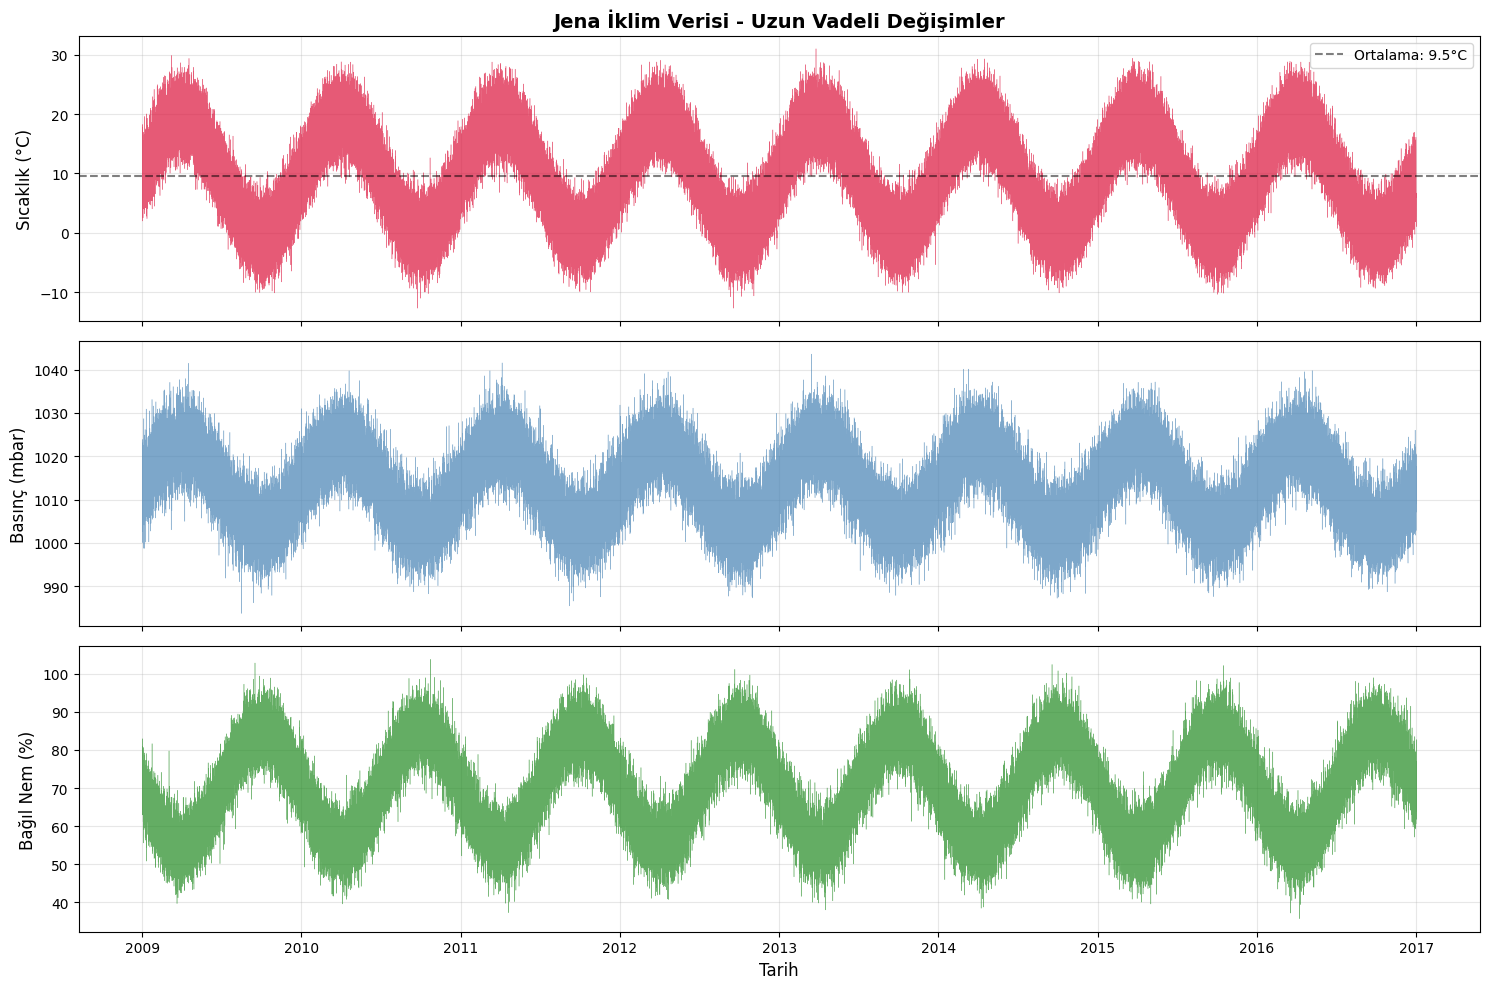

In [ ]:
# Tarih sütununu işleyelim
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
df = df.dropna(subset=['Date Time'])
df = df.set_index('Date Time')
df = df.sort_index()

# İstatistiksel özet
print("Sıcaklık İstatistikleri:")
print(f"  Ortalama: {df['T (degC)'].mean():.2f} °C")
print(f"  Std Sapma: {df['T (degC)'].std():.2f} °C")
print(f"  Min: {df['T (degC)'].min():.2f} °C")
print(f"  Maks: {df['T (degC)'].max():.2f} °C")

# Figure 1: Uzun vadeli sıcaklık trendi
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# 1. Sıcaklık
axes[0].plot(df.index, df['T (degC)'], color='crimson', linewidth=0.3, alpha=0.7)
axes[0].set_ylabel('Sıcaklık (°C)', fontsize=12)
axes[0].set_title('Jena İklim Verisi - Uzun Vadeli Değişimler', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=df['T (degC)'].mean(), color='black', linestyle='--', alpha=0.5, label=f'Ortalama: {df["T (degC)"].mean():.1f}°C')
axes[0].legend(fontsize=10)

# 2. Basınç
if 'p (mbar)' in df.columns:
    axes[1].plot(df.index, df['p (mbar)'], color='steelblue', linewidth=0.3, alpha=0.7)
    axes[1].set_ylabel('Basınç (mbar)', fontsize=12)
    axes[1].grid(True, alpha=0.3)

# 3. Bağıl Nem
if 'rh (%)' in df.columns:
    axes[2].plot(df.index, df['rh (%)'], color='forestgreen', linewidth=0.3, alpha=0.7)
    axes[2].set_ylabel('Bağıl Nem (%)', fontsize=12)
    axes[2].grid(True, alpha=0.3)

axes[2].set_xlabel('Tarih', fontsize=12)
plt.tight_layout()
plt.show()

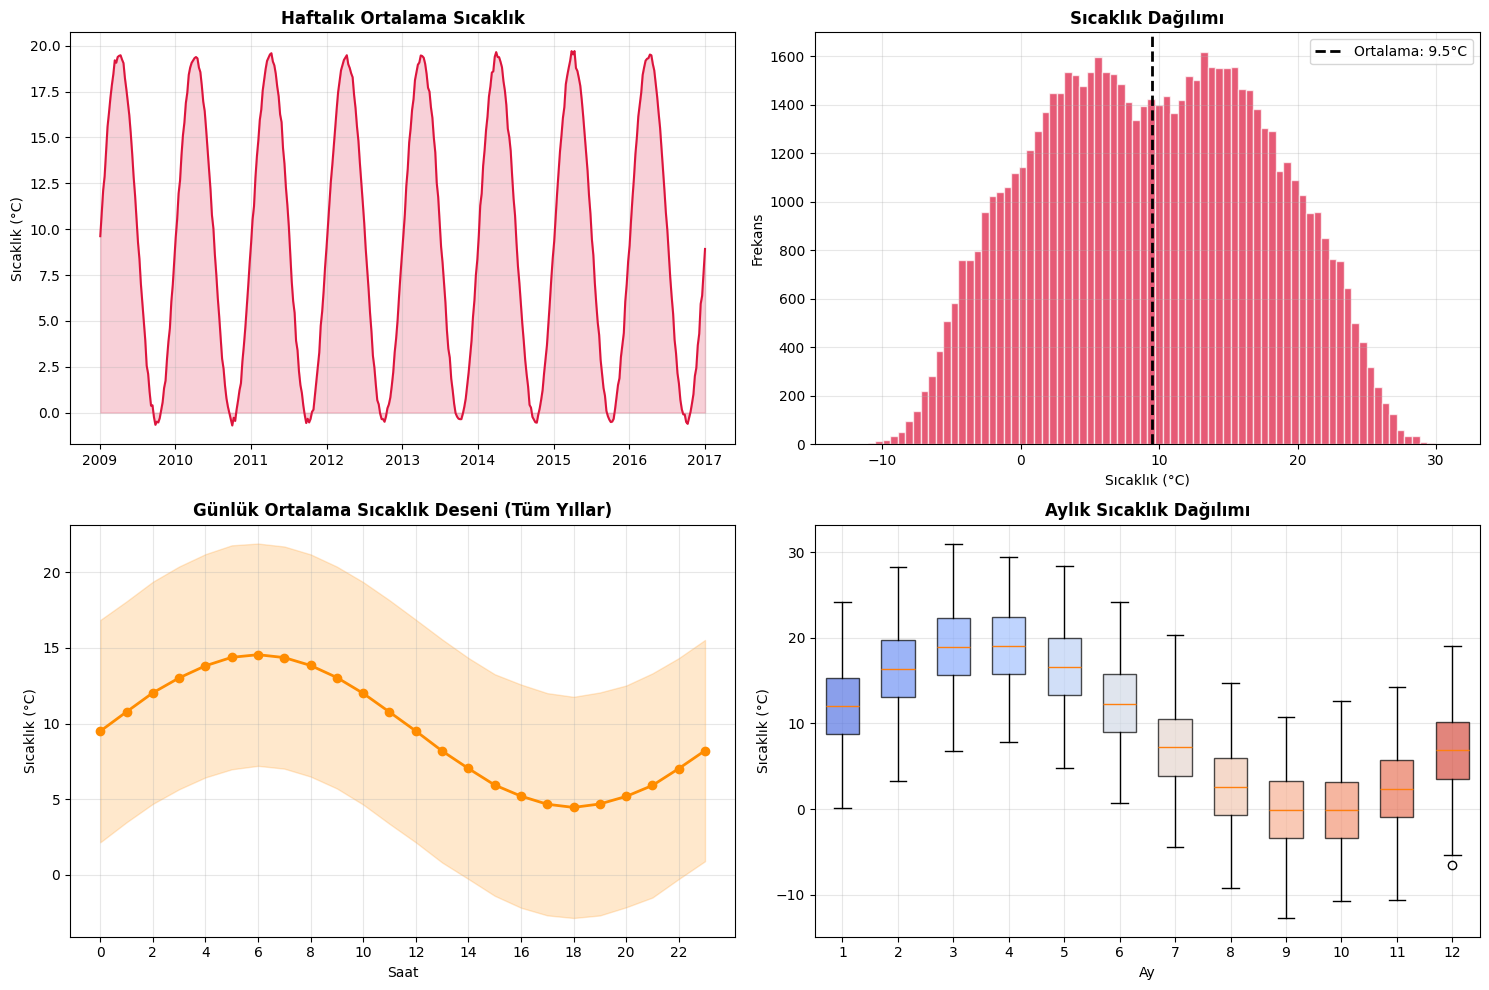

In [ ]:
# Figure 2: Detaylı analiz
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Haftalık ortalama sıcaklık (daha okunabilir)
temp_weekly = df['T (degC)'].resample('W').mean()
axes[0, 0].plot(temp_weekly.index, temp_weekly, color='crimson', linewidth=1.5)
axes[0, 0].fill_between(temp_weekly.index, temp_weekly, alpha=0.2, color='crimson')
axes[0, 0].set_title('Haftalık Ortalama Sıcaklık', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Sıcaklık (°C)')
axes[0, 0].grid(True, alpha=0.3)

# Sıcaklık dağılımı
axes[0, 1].hist(df['T (degC)'], bins=80, color='crimson', alpha=0.7, edgecolor='white')
axes[0, 1].axvline(x=df['T (degC)'].mean(), color='black', linestyle='--', linewidth=2, label=f'Ortalama: {df["T (degC)"].mean():.1f}°C')
axes[0, 1].set_title('Sıcaklık Dağılımı', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sıcaklık (°C)')
axes[0, 1].set_ylabel('Frekans')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Günlük saatlik desen (ortalama)
df['hour'] = df.index.hour
hourly_pattern = df.groupby('hour')['T (degC)'].agg(['mean', 'std'])
axes[1, 0].plot(hourly_pattern.index, hourly_pattern['mean'], 'o-', color='darkorange', linewidth=2, markersize=6)
axes[1, 0].fill_between(hourly_pattern.index,
                        hourly_pattern['mean'] - hourly_pattern['std'],
                        hourly_pattern['mean'] + hourly_pattern['std'],
                        alpha=0.2, color='darkorange')
axes[1, 0].set_title('Günlük Ortalama Sıcaklık Deseni (Tüm Yıllar)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Saat')
axes[1, 0].set_ylabel('Sıcaklık (°C)')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

# Aylık kutu grafiği
df['month'] = df.index.month
monthly_data = [df[df['month'] == m]['T (degC)'].values for m in range(1, 13)]
bp = axes[1, 1].boxplot(monthly_data, labels=[str(m) for m in range(1, 13)],
                         patch_artist=True, widths=0.6)
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, 12))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Aylık Sıcaklık Dağılımı', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Ay')
axes[1, 1].set_ylabel('Sıcaklık (°C)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

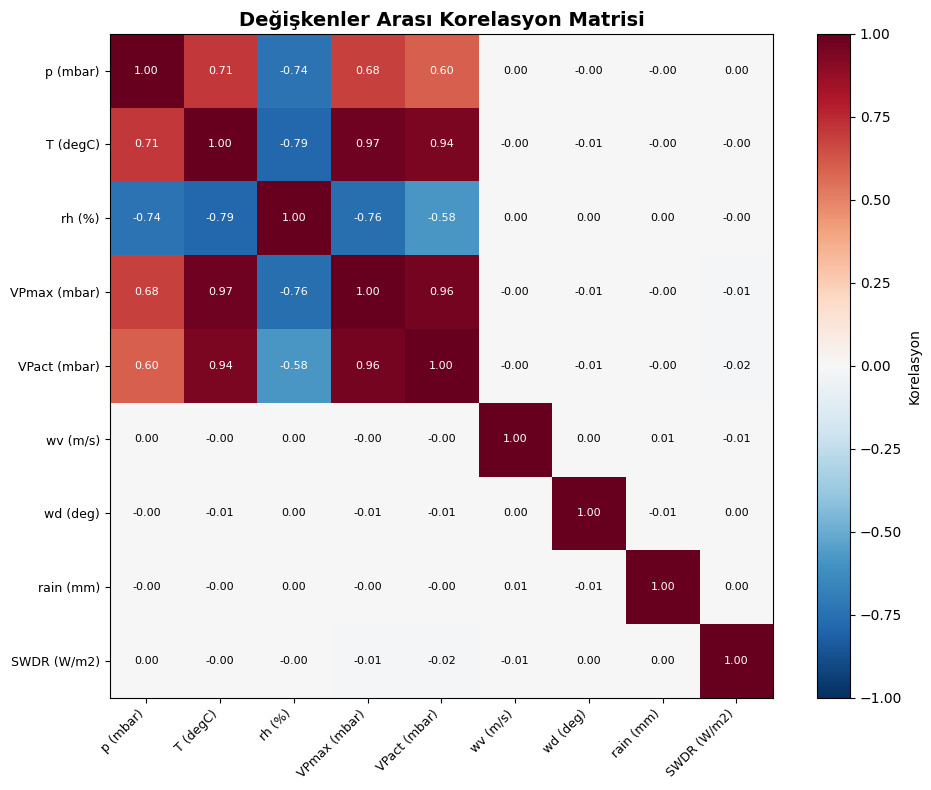

In [ ]:
# Korelasyon matrisi
numerical_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['hour', 'month']]

if len(numerical_cols) > 1:
    corr_matrix = df[numerical_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numerical_cols)))
    ax.set_yticks(range(len(numerical_cols)))
    ax.set_xticklabels(numerical_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numerical_cols, fontsize=9)

    # Korelasyon değerlerini yazdır
    for i in range(len(numerical_cols)):
        for j in range(len(numerical_cols)):
            ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                   ha='center', va='center', fontsize=8,
                   color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

    plt.colorbar(im, ax=ax, label='Korelasyon')
    ax.set_title('Değişkenler Arası Korelasyon Matrisi', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 3. Veri Ön İşleme

LSTM modeli için veriyi hazırlayacağız:
1. **Normalizasyon**: MinMaxScaler ile veriyi [0, 1] aralığına getirme
2. **Sequence Oluşturma**: Saatlik verileri 24 saatlik pencereler halinde gruplama
3. **Eğitim/Validation/Test Ayırma**: Zamansal sırayı koruyarak bölmek (shuffling yapmayacağız!)

> **Not:** Zaman serisi verilerinde shuffle yapmamak çok önemlidir. Gelecekteki verileri geçmişle karıştırmak "veri sızıntısına" (data leakage) yol açar.

In [ ]:
# Hedef değişken: Sıcaklık
TARGET_COL = 'T (degC)'

# Tüm sayısal sütunları kullanalım (multi-variate input, univariate output)
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in ['hour', 'month']]

data = df[feature_cols].values.copy()
target_idx = feature_cols.index(TARGET_COL)

print(f"Özellik sayısı: {len(feature_cols)}")
print(f"Kullanılan özellikler: {feature_cols}")
print(f"Hedef değişken indeksi: {target_idx} ({TARGET_COL})")
print(f"Toplam örnek sayısı: {len(data)}")

Özellik sayısı: 9
Kullanılan özellikler: ['p (mbar)', 'T (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'wv (m/s)', 'wd (deg)', 'rain (mm)', 'SWDR (W/m2)']
Hedef değişken indeksi: 1 (T (degC))
Toplam örnek sayısı: 70128


In [ ]:
# Eksik değer temizleme
df_clean = df[feature_cols].dropna()
data = df_clean.values.copy()

print(f"Temizlenmiş veri boyutu: {data.shape}")

# MinMaxScaler ile normalizasyon
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

print(f"\nNormalizasyon sonrası:")
print(f"  Min değerler: {data_scaled.min(axis=0).round(4)}")
print(f"  Maks değerler: {data_scaled.max(axis=0).round(4)}")

Temizlenmiş veri boyutu: (70128, 9)

Normalizasyon sonrası:
  Min değerler: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Maks değerler: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
def create_sequences(data, target_idx, window_size, forecast_horizon=1):
    """
    Zaman serisi verisinden sequence'lar oluşturur.

    Args:
        data: Normalizasyonu yapılmış veri (n_samples, n_features)
        target_idx: Hedef değişkenin sütun indeksi
        window_size: Girdi pencere boyutu (kaç saatlik geçmiş)
        forecast_horizon: Kaç adım ilerisi tahmin edilecek

    Returns:
        X: Girdi sequence'ları (n_samples, window_size, n_features)
        y: Hedef değerler (n_samples, forecast_horizon)
    """
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size:i + window_size + forecast_horizon, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Pencere boyutu: 24 saat (1 günlük geçmiş)
WINDOW_SIZE = 24
FORECAST_HORIZON = 1

X, y = create_sequences(data_scaled, target_idx, WINDOW_SIZE, FORECAST_HORIZON)

print(f"Oluşturulan sequence boyutları:")
print(f"  X shape: {X.shape} -> (örnekler, zaman_adımı, özellik_sayısı)")
print(f"  y shape: {y.shape} -> (örnekler, tahmin_adımı)")

Oluşturulan sequence boyutları:
  X shape: (70104, 24, 9) -> (örnekler, zaman_adımı, özellik_sayısı)
  y shape: (70104, 1) -> (örnekler, tahmin_adımı)


In [ ]:
# Zamansal sırayı koruyarak bölme (shuffle YOK!)
n_samples = len(X)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_end = int(n_samples * train_ratio)
val_end = int(n_samples * (train_ratio + val_ratio))

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"Eğitim seti:    {X_train.shape[0]} örnek ({X_train.shape[0]/n_samples*100:.1f}%)")
print(f"Doğrulama seti: {X_val.shape[0]} örnek ({X_val.shape[0]/n_samples*100:.1f}%)")
print(f"Test seti:      {X_test.shape[0]} örnek ({X_test.shape[0]/n_samples*100:.1f}%)")

# DataLoader oluştur
BATCH_SIZE = 64

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nEğitim batch sayısı: {len(train_loader)}")
print(f"Doğrulama batch sayısı: {len(val_loader)}")
print(f"Test batch sayısı: {len(test_loader)}")

# Bir örneğe bakalım
sample_X, sample_y = next(iter(train_loader))
print(f"\nBatch örnekleri:")
print(f"  X batch shape: {sample_X.shape}")
print(f"  y batch shape: {sample_y.shape}")

Eğitim seti:    49072 örnek (70.0%)
Doğrulama seti: 10516 örnek (15.0%)
Test seti:      10516 örnek (15.0%)

Eğitim batch sayısı: 767
Doğrulama batch sayısı: 165
Test batch sayısı: 165

Batch örnekleri:
  X batch shape: torch.Size([64, 24, 9])
  y batch shape: torch.Size([64, 1])


## 4. LSTM Kapılarını Anlamak

LSTM (Long Short-Term Memory), standart RNN'lerin uzun vadeli bağımlılıkları öğrenme sorununu çözmek için geliştirilmiş bir mimaridir.

### LSTM'in 4 Temel Bileşeni:

#### 1. **Unutma Kapısı (Forget Gate)** - "Neyi unutmalıyım?"
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
- Hücre durumundan hangi bilgiyi atacağımızı belirler
- 0 = tamamen unut, 1 = tamamen koru

#### 2. **Giriş Kapısı (Input Gate)** - "Yeni ne eklemeliyim?"
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$
- Hücre durumuna yeni bilgi eklemek için kullanılır
- Hangi değerleri güncelleyeceğimizi ve yeni aday değerleri belirler

#### 3. **Hücre Durumu Güncelleme** - "Belleği güncellemek"
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
- Eski bilgiyi unut + yeni bilgiyi ekle

#### 4. **Çıkış Kapısı (Output Gate)** - "Neyi dışarı vermeliyim?"
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$
- Hücre durumundan güncellenmiş gizli durumu çıkarır

### Neden LSTM, RNN'den Daha İyi?
- **Gradient flowing** sorunu: Unutma kapısı sayesinde uzun vadeli bağımlılıkları korur
- **Seçici hatırlama**: Önemli bilgiyi uzun süre hatırlayabilir
- **Seçici unutma**: Gereksiz bilgiyi temizleyebilir

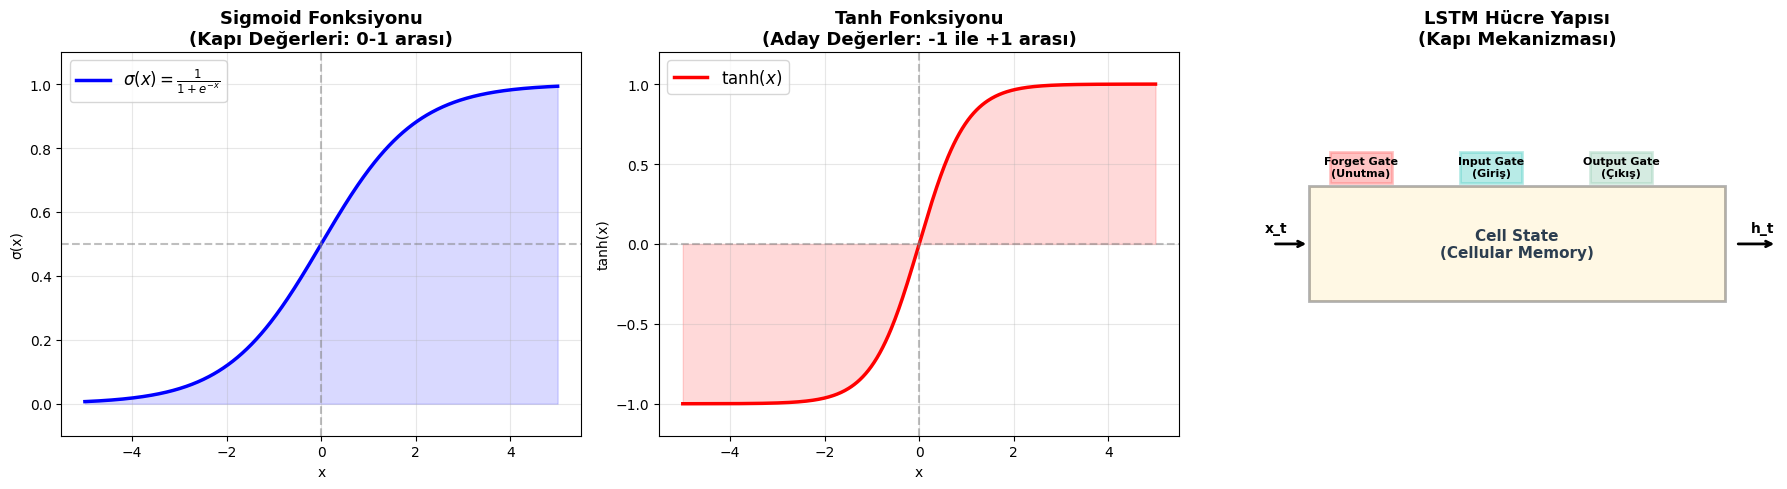


LSTM vs Vanilla RNN - Temel Farklar:
  Vanilla RNN: Tek bir tanh katmanı, kısa vadeli bağımlılıklar
  LSTM: 4 kapı mekanizması, uzun vadeli bağımlılıklar
  
  Unutma Kapısı  -> Uzun vadeli gereksiz bilgiyi temizler
  Giriş Kapısı   -> Yeni anlamlı bilgiyi ekler
  Hücre Durumu   -> Gradient akışını koruyan "otoyol"
  Çıkış Kapısı   -> Çıktıyı filtreler


In [ ]:
# Aktivasyon fonksiyonlarını görselleştirelim
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.linspace(-5, 5, 500)

# Sigmoid
sigmoid = 1 / (1 + np.exp(-x))
axes[0].plot(x, sigmoid, 'b-', linewidth=2.5, label=r'$\sigma(x) = \frac{1}{1+e^{-x}}$')
axes[0].fill_between(x, sigmoid, alpha=0.15, color='blue')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sigmoid Fonksiyonu\n(Kapı Değerleri: 0-1 arası)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('σ(x)')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.1)

# Tanh
tanh = np.tanh(x)
axes[1].plot(x, tanh, 'r-', linewidth=2.5, label=r'$\tanh(x)$')
axes[1].fill_between(x, tanh, alpha=0.15, color='red')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Tanh Fonksiyonu\n(Aday Değerler: -1 ile +1 arası)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('tanh(x)')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.2, 1.2)

# Gate mekanizması şeması (metin tabanlı)
axes[2].set_xlim(0, 10)
axes[2].set_ylim(0, 10)
axes[2].axis('off')
axes[2].set_title('LSTM Hücre Yapısı\n(Kapı Mekanizması)', fontsize=13, fontweight='bold')

# Şema çizimi
gate_colors = {'forget': '#FF6B6B', 'input': '#4ECDC4', 'cell': '#45B7D1', 'output': '#96CEB4'}

# Hücre gövdesi
cell_rect = plt.Rectangle((1, 3.5), 8, 3, linewidth=2, edgecolor='black',
                          facecolor='#FFEAA7', alpha=0.3)
axes[2].add_patch(cell_rect)

# Kapılar
gates = [
    (2, 7, 'Forget Gate\n(Unutma)', gate_colors['forget']),
    (4.5, 7, 'Input Gate\n(Giriş)', gate_colors['input']),
    (7, 7, 'Output Gate\n(Çıkış)', gate_colors['output']),
]

for gx, gy, label, color in gates:
    rect = plt.Rectangle((gx-0.6, gy-0.4), 1.2, 0.8, linewidth=2,
                         edgecolor=color, facecolor=color, alpha=0.4)
    axes[2].add_patch(rect)
    axes[2].text(gx, gy, label, ha='center', va='center', fontsize=8, fontweight='bold')

# Hücre durumu yazısı
axes[2].text(5, 5, 'Cell State\n(Cellular Memory)', ha='center', va='center',
            fontsize=11, fontweight='bold', color='#2C3E50')

# Giriş ve çıkış okları
axes[2].annotate('', xy=(1, 5), xytext=(0.3, 5),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
axes[2].text(0.15, 5.3, 'x_t', fontsize=10, fontweight='bold')

axes[2].annotate('', xy=(10, 5), xytext=(9.2, 5),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
axes[2].text(9.5, 5.3, 'h_t', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("LSTM vs Vanilla RNN - Temel Farklar:")
print("=" * 60)
print("  Vanilla RNN: Tek bir tanh katmanı, kısa vadeli bağımlılıklar")
print("  LSTM: 4 kapı mekanizması, uzun vadeli bağımlılıklar")
print("  ")
print("  Unutma Kapısı  -> Uzun vadeli gereksiz bilgiyi temizler")
print("  Giriş Kapısı   -> Yeni anlamlı bilgiyi ekler")
# Çözüm: Dıştaki tırnakları tek tırnağa çevirdik
print('  Hücre Durumu   -> Gradient akışını koruyan "otoyol"')
print("  Çıkış Kapısı   -> Çıktıyı filtreler")

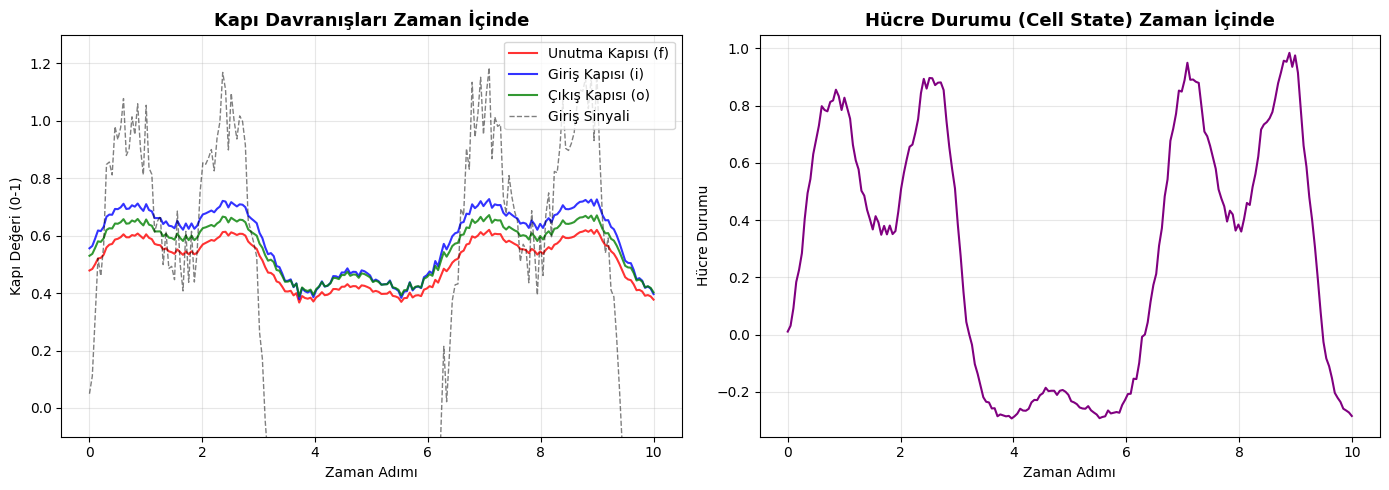

In [ ]:
# Gate davranışının animasyonu - zaman adımında kapı değerleri
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentetik bir zaman serisi örneği ile gate davranışını göster
np.random.seed(42)
t = np.linspace(0, 10, 200)

# Basit bir sinyal
signal = np.sin(t) + 0.5 * np.sin(3*t) + np.random.normal(0, 0.1, len(t))

# Basit LSTM benzeri hesaplama (gerçek LSTM değil, sadece kavramsal)
forget_gates = []
input_gates = []
output_gates = []
cell_states = []

cell_state = 0
hidden_state = 0

for i in range(len(t)):
    x = signal[i]
    # Basit ağırlıklar
    f_gate = 1 / (1 + np.exp(-(0.5 * hidden_state + 0.3 * x - 0.1)))  # unut
    i_gate = 1 / (1 + np.exp(-(0.4 * hidden_state + 0.5 * x + 0.2)))  # gir
    candidate = np.tanh(0.3 * hidden_state + 0.4 * x)  # aday
    o_gate = 1 / (1 + np.exp(-(0.3 * hidden_state + 0.4 * x + 0.1)))  # çık

    cell_state = f_gate * cell_state + i_gate * candidate
    hidden_state = o_gate * np.tanh(cell_state)

    forget_gates.append(f_gate)
    input_gates.append(i_gate)
    output_gates.append(o_gate)
    cell_states.append(cell_state)

axes[0].plot(t, forget_gates, 'r-', linewidth=1.5, label='Unutma Kapısı (f)', alpha=0.8)
axes[0].plot(t, input_gates, 'b-', linewidth=1.5, label='Giriş Kapısı (i)', alpha=0.8)
axes[0].plot(t, output_gates, 'g-', linewidth=1.5, label='Çıkış Kapısı (o)', alpha=0.8)
axes[0].plot(t, signal, 'k--', linewidth=1, label='Giriş Sinyali', alpha=0.5)
axes[0].set_title('Kapı Davranışları Zaman İçinde', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Zaman Adımı')
axes[0].set_ylabel('Kapı Değeri (0-1)')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.3)

axes[1].plot(t, cell_states, 'purple', linewidth=1.5)
axes[1].set_title('Hücre Durumu (Cell State) Zaman İçinde', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Zaman Adımı')
axes[1].set_ylabel('Hücre Durumu')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. LSTM Modeli Eğitimi

İki katmanlı bir LSTM modeli tanımlayacağız:
- **Giriş katmanı**: LSTM (128 birim, batch_first=True)
- **İkinci katman**: LSTM (64 birim)
- **Tam bağlı katman**: Çıkış katmanı (1 değer = sıcaklık tahmini)

Eğitim detayları:
- **Kaybı fonksiyonu**: MSE (Mean Squared Error)
- **Optimizasyon**: Adam
- **Öğrenme oranı zamanlaması**: ReduceLROnPlateau benzeri manuel uygulama
- **Gradient Clipping**: Gradient patlamasını önlemek için max_norm=1.0
- **Erken durdurma (Early Stopping)**: Doğrulama kaybı iyileşmediğinde durdurma

In [ ]:
class WeatherLSTM(nn.Module):
    """
    İklim verisi için LSTM tabanlı tahmin modeli.

    Mimari:
        Input -> LSTM katman 1 -> Dropout -> LSTM katman 2 -> Dropout -> FC -> Output
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 output_size=1, dropout=0.2):
        super(WeatherLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM katmanları
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,  # (batch, seq, feature) formatı
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Dropout katmanı
        self.dropout = nn.Dropout(dropout)

        # Tam bağlı çıkış katmanı
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        batch_size = x.size(0)

        # Başlangıç gizli durumları (sıfır ile başlat)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # LSTM ileri geçişi
        lstm_out, (hn, cn) = self.lstm(x, (h0, c0))

        # Son zaman adımının çıktısını al
        last_output = lstm_out[:, -1, :]  # (batch_size, hidden_size)

        # Dropout ve tam bağlı katman
        out = self.dropout(last_output)
        out = self.fc(out)  # (batch_size, output_size)

        return out

# Modeli oluştur
input_size = X_train.shape[2]  # özellik sayısı
model = WeatherLSTM(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    output_size=FORECAST_HORIZON,
    dropout=0.2
).to(device)

print(model)
print(f"\nToplam parametre sayısı: {sum(p.numel() for p in model.parameters()):,}")
print(f"Eğitilebilir parametre: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

WeatherLSTM(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Toplam parametre sayısı: 203,393
Eğitilebilir parametre: 203,393


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

def train_model(model, train_loader, val_loader, num_epochs=30,
                learning_rate=0.001, patience=7, model_name='LSTM'):
    """
    LSTM modelini eğitir. Early stopping ve LR scheduling içerir.

    Returns:
        history: Eğitim geçmişi (train_loss, val_loss, gradient_norms)
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    # Güncelleme: PyTorch'un yeni sürümleriyle uyum için 'verbose' parametresi kaldırıldı
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'lr': [],
        'grad_norms': []
    }

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"{model_name} Modeli Eğitimi Başlıyor")
    print(f"{'='*60}")
    print(f"Epoch: {num_epochs}, LR: {learning_rate}, Batch: {train_loader.batch_size}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):
        # --- Eğitim aşaması ---
        model.train()
        train_loss = 0.0
        epoch_grad_norms = []

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()

            # Gradient clipping (gradient patlamasını önleme)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Gradient normunu kaydet
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            total_norm = total_norm ** 0.5
            epoch_grad_norms.append(total_norm)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        avg_grad_norm = np.mean(epoch_grad_norms)

        # --- Doğrulama aşaması ---
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                val_loss += criterion(outputs, batch_y).item()

        val_loss /= len(val_loader)

        # LR güncelleme
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)

        # Geçmiş kaydetme
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)
        history['grad_norms'].append(avg_grad_norm)

        # En iyi modeli kaydetme
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = ' *** Yeni en iyi model ***'
        else:
            patience_counter += 1
            marker = ''

        # Yazdırma (her 5 epoch'ta bir veya önemli anlarda)
        if (epoch + 1) % 5 == 0 or epoch == 0 or marker:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
                  f"Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"LR: {current_lr:.6f} | "
                  f"Grad Norm: {avg_grad_norm:.4f}{marker}")

        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping uygulandı! Model {epoch+1}. epochta durdu.")
            break

    # En iyi modeli geri yükle
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nEn iyi model yüklendi. En iyi Validation Loss: {best_val_loss:.6f}")

    return history

# LSTM modelini eğit
lstm_history = train_model(
    model, train_loader, val_loader,
    num_epochs=30,
    learning_rate=0.001,
    patience=7,
    model_name='LSTM'
)


LSTM Modeli Eğitimi Başlıyor
Epoch: 30, LR: 0.001, Batch: 64

Epoch [  1/30] Train Loss: 0.007179 | Val Loss: 0.002810 | LR: 0.001000 | Grad Norm: 0.0833 *** Yeni en iyi model ***
Epoch [  2/30] Train Loss: 0.003355 | Val Loss: 0.002351 | LR: 0.001000 | Grad Norm: 0.0541 *** Yeni en iyi model ***
Epoch [  3/30] Train Loss: 0.003079 | Val Loss: 0.002301 | LR: 0.001000 | Grad Norm: 0.0454 *** Yeni en iyi model ***
Epoch [  5/30] Train Loss: 0.002863 | Val Loss: 0.002650 | LR: 0.001000 | Grad Norm: 0.0391
Epoch [  8/30] Train Loss: 0.002577 | Val Loss: 0.002266 | LR: 0.000500 | Grad Norm: 0.0295 *** Yeni en iyi model ***
Epoch [  9/30] Train Loss: 0.002551 | Val Loss: 0.002255 | LR: 0.000500 | Grad Norm: 0.0288 *** Yeni en iyi model ***
Epoch [ 10/30] Train Loss: 0.002552 | Val Loss: 0.002299 | LR: 0.000500 | Grad Norm: 0.0290
Epoch [ 15/30] Train Loss: 0.002416 | Val Loss: 0.002243 | LR: 0.000250 | Grad Norm: 0.0256 *** Yeni en iyi model ***
Epoch [ 20/30] Train Loss: 0.002359 | Val Los

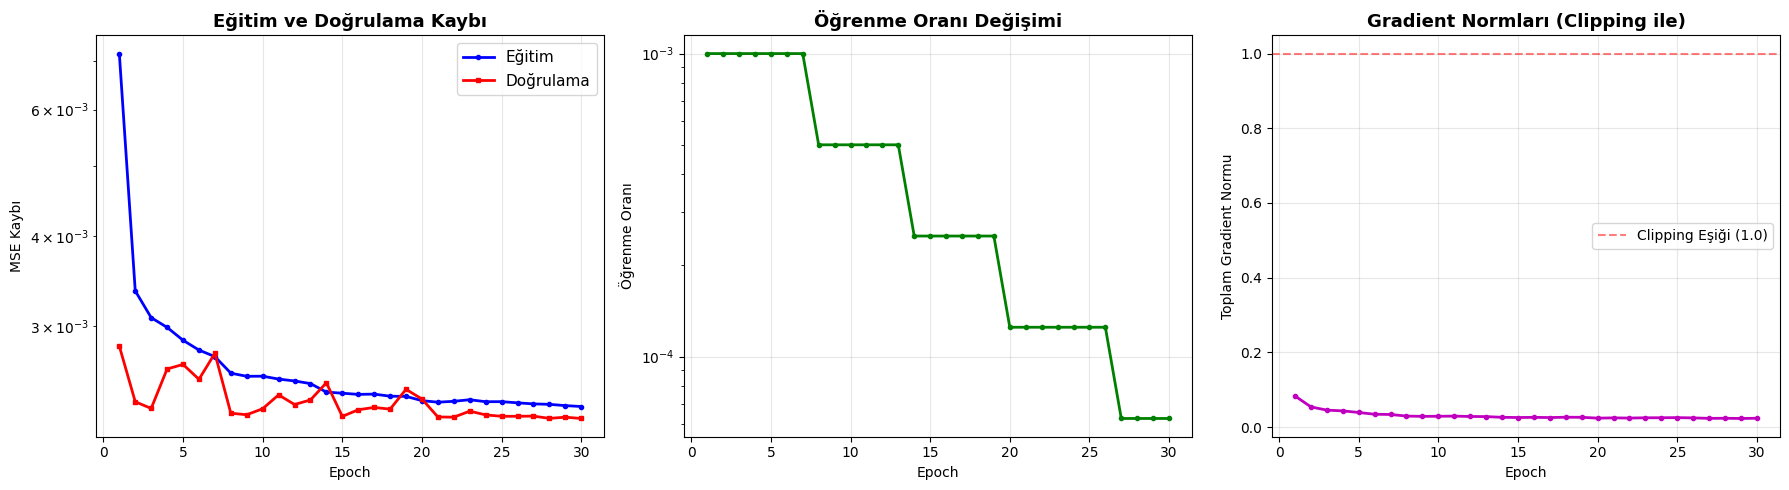

In [ ]:
# Eğitim grafikleri
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(lstm_history['train_loss']) + 1)

# Kayıp eğrisi
axes[0].plot(epochs, lstm_history['train_loss'], 'b-', linewidth=2, label='Eğitim', marker='o', markersize=3)
axes[0].plot(epochs, lstm_history['val_loss'], 'r-', linewidth=2, label='Doğrulama', marker='s', markersize=3)
axes[0].set_title('Eğitim ve Doğrulama Kaybı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Kaybı')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Öğrenme oranı
axes[1].plot(epochs, lstm_history['lr'], 'g-', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Öğrenme Oranı Değişimi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Öğrenme Oranı')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Gradient normları
axes[2].plot(epochs, lstm_history['grad_norms'], 'm-', linewidth=2, marker='o', markersize=3)
axes[2].axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Clipping Eşiği (1.0)')
axes[2].set_title('Gradient Normları (Clipping ile)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Toplam Gradient Normu')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. RNN vs LSTM Karşılaştırması

Aynı veri seti üzerinde Vanilla RNN modelini de eğiterek LSTM ile karşılaştıralım.

**Beklenen Farklar:**
- Vanilla RNN, gradient kaybı (vanishing gradient) nedeniyle uzun vadeli bağımlılıkları öğrenmekte zorlanır
- LSTM, unutma kapısı sayesinde daha istikrarlı gradient akışı sağlar
- Gerçek hava durumu verisinde bu fark, mevsimsal ve günlük döngüleri yakalamada görülebilir

In [ ]:
class WeatherRNN(nn.Module):
    """Vanilla RNN modeli (LSTM ile karşılaştırma için)"""
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 output_size=1, dropout=0.2):
        super(WeatherRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            nonlinearity='tanh'
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        rnn_out, hn = self.rnn(x, h0)
        last_output = rnn_out[:, -1, :]
        out = self.dropout(last_output)
        out = self.fc(out)
        return out

# Vanilla RNN modelini oluştur ve eğit
rnn_model = WeatherRNN(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    output_size=FORECAST_HORIZON,
    dropout=0.2
).to(device)

rnn_history = train_model(
    rnn_model, train_loader, val_loader,
    num_epochs=30,
    learning_rate=0.001,
    patience=7,
    model_name='Vanilla RNN'
)


Vanilla RNN Modeli Eğitimi Başlıyor
Epoch: 30, LR: 0.001, Batch: 64

Epoch [  1/30] Train Loss: 0.004789 | Val Loss: 0.002818 | LR: 0.001000 | Grad Norm: 0.1059 *** Yeni en iyi model ***
Epoch [  2/30] Train Loss: 0.003275 | Val Loss: 0.002632 | LR: 0.001000 | Grad Norm: 0.0747 *** Yeni en iyi model ***
Epoch [  5/30] Train Loss: 0.002946 | Val Loss: 0.002455 | LR: 0.001000 | Grad Norm: 0.0563 *** Yeni en iyi model ***
Epoch [  8/30] Train Loss: 0.002756 | Val Loss: 0.002440 | LR: 0.001000 | Grad Norm: 0.0480 *** Yeni en iyi model ***
Epoch [ 10/30] Train Loss: 0.002727 | Val Loss: 0.002485 | LR: 0.001000 | Grad Norm: 0.0469
Epoch [ 14/30] Train Loss: 0.002590 | Val Loss: 0.002410 | LR: 0.000500 | Grad Norm: 0.0426 *** Yeni en iyi model ***
Epoch [ 15/30] Train Loss: 0.002542 | Val Loss: 0.002494 | LR: 0.000500 | Grad Norm: 0.0398
Epoch [ 16/30] Train Loss: 0.002567 | Val Loss: 0.002380 | LR: 0.000500 | Grad Norm: 0.0434 *** Yeni en iyi model ***
Epoch [ 18/30] Train Loss: 0.002532 | 

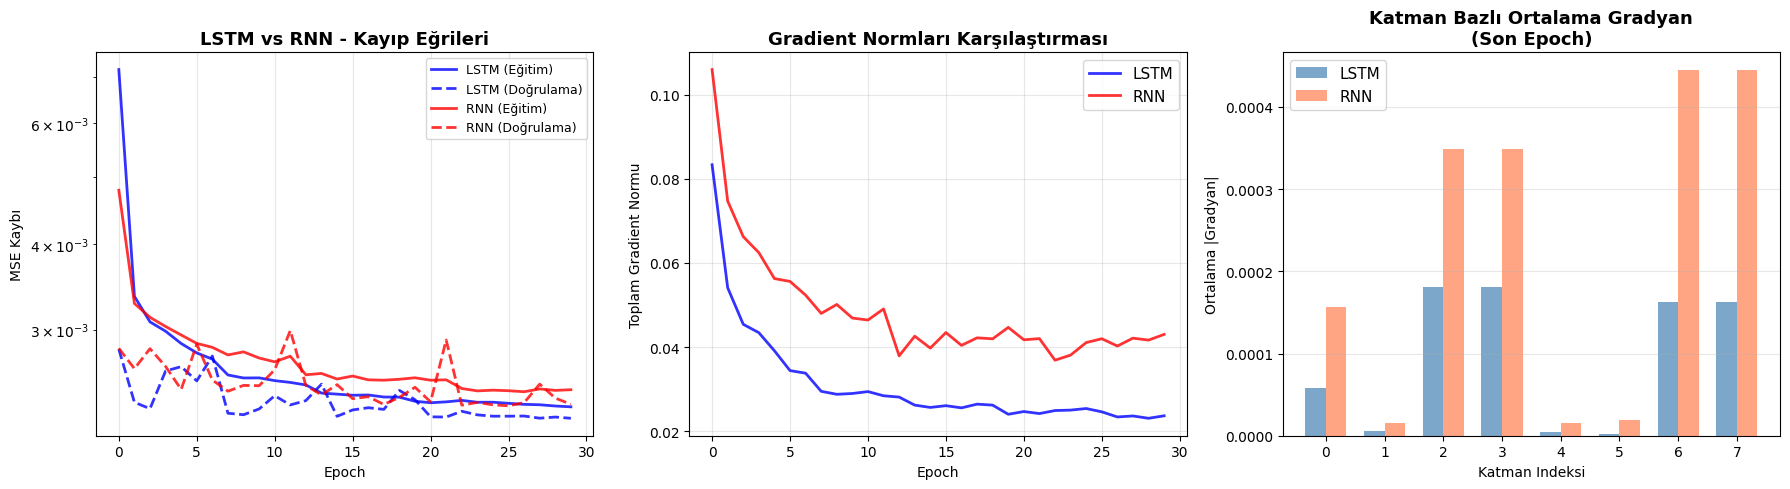


EĞİTİM SONUCU KARŞILAŞTIRMASI
LSTM - Son Eğitim Loss:    0.002315
LSTM - Son Doğrulama Loss: 0.002228
LSTM - En İyi Doğrulama:   0.002228

RNN  - Son Eğitim Loss:    0.002452
RNN  - Son Doğrulama Loss: 0.002336
RNN  - En İyi Doğrulama:   0.002323


In [ ]:
# Karşılaştırma grafikleri
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Kayıp eğrisi karşılaştırması
axes[0].plot(lstm_history['train_loss'], 'b-', linewidth=2, label='LSTM (Eğitim)', alpha=0.8)
axes[0].plot(lstm_history['val_loss'], 'b--', linewidth=2, label='LSTM (Doğrulama)', alpha=0.8)
axes[0].plot(rnn_history['train_loss'], 'r-', linewidth=2, label='RNN (Eğitim)', alpha=0.8)
axes[0].plot(rnn_history['val_loss'], 'r--', linewidth=2, label='RNN (Doğrulama)', alpha=0.8)
axes[0].set_title('LSTM vs RNN - Kayıp Eğrileri', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Kaybı')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Gradient normları karşılaştırması
axes[1].plot(lstm_history['grad_norms'], 'b-', linewidth=2, label='LSTM', alpha=0.8)
axes[1].plot(rnn_history['grad_norms'], 'r-', linewidth=2, label='RNN', alpha=0.8)
axes[1].set_title('Gradient Normları Karşılaştırması', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Toplam Gradient Normu')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Parametre gradyan dağılımı (son epoch)
lstm_grads = []
rnn_grads = []

for name, param in rnn_model.named_parameters():
    if param.grad is not None and 'rnn' in name:
        rnn_grads.append(param.grad.data.abs().mean().item())

for name, param in model.named_parameters():
    if param.grad is not None and 'lstm' in name:
        lstm_grads.append(param.grad.data.abs().mean().item())

if lstm_grads and rnn_grads:
    x_pos = np.arange(max(len(lstm_grads), len(rnn_grads)))
    width = 0.35

    # Eşit uzunlukta olması için pad
    lstm_padded = lstm_grads + [0] * (len(x_pos) - len(lstm_grads))
    rnn_padded = rnn_grads + [0] * (len(x_pos) - len(rnn_grads))

    axes[2].bar(x_pos - width/2, lstm_padded, width, label='LSTM', color='steelblue', alpha=0.7)
    axes[2].bar(x_pos + width/2, rnn_padded, width, label='RNN', color='coral', alpha=0.7)
    axes[2].set_title('Katman Bazlı Ortalama Gradyan\n(Son Epoch)', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Katman Indeksi')
    axes[2].set_ylabel('Ortalama |Gradyan|')
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3, axis='y')
else:
    axes[2].text(0.5, 0.5, 'Gradyan bilgisi\ndifferent.', ha='center', va='center',
                transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title('Katman Bazlı Gradyan Dağılımı', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Final doğrulama karşılaştırması
print("\n" + "=" * 50)
print("EĞİTİM SONUCU KARŞILAŞTIRMASI")
print("=" * 50)
print(f"LSTM - Son Eğitim Loss:    {lstm_history['train_loss'][-1]:.6f}")
print(f"LSTM - Son Doğrulama Loss: {lstm_history['val_loss'][-1]:.6f}")
print(f"LSTM - En İyi Doğrulama:   {min(lstm_history['val_loss']):.6f}")
print()
print(f"RNN  - Son Eğitim Loss:    {rnn_history['train_loss'][-1]:.6f}")
print(f"RNN  - Son Doğrulama Loss: {rnn_history['val_loss'][-1]:.6f}")
print(f"RNN  - En İyi Doğrulama:   {min(rnn_history['val_loss']):.6f}")

## 7. Tahmin Değerlendirmesi

Test seti üzerinde LSTM modelinin performansını değerlendireceğiz:

**Metrikler:**
- **RMSE (Root Mean Squared Error)**: Ortalama hata büyüklüğü (°C)
- **MAE (Mean Absolute Error)**: Ortalama mutlak hata (°C)
- **R² (Determination Katsayısı)**: Modelin açıkladığı varyans oranı (1.0 = mükemmel)

**Görselleştirmeler:**
- Gerçek vs Tahmin edilen sıcaklık zaman serisi
- Saçılım grafiği (scatter plot)
- Hata dağılımı histogramı

In [ ]:
def evaluate_model(model, test_loader, scaler, target_idx, feature_cols, device):
    """
    Test seti üzerinde modeli değerlendirir.

    Returns:
        y_true, y_pred: Gerçek ve tahmin değerleri (normalizasyonu geri alınmış)
        metrics: Metrik sözlüğü
    """
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(batch_y.numpy())

    y_pred_scaled = np.concatenate(all_preds, axis=0)
    y_true_scaled = np.concatenate(all_targets, axis=0)

    # Normalizasyonu geri al
    # inverse_transform için tam boyutlu array gerekiyor
    n_features = len(feature_cols)

    # Tahminler için
    y_pred_full = np.zeros((len(y_pred_scaled), n_features))
    y_pred_full[:, target_idx] = y_pred_scaled.flatten()
    y_pred_inv = scaler.inverse_transform(y_pred_full)[:, target_idx]

    # Gerçek değerler için
    y_true_full = np.zeros((len(y_true_scaled), n_features))
    y_true_full[:, target_idx] = y_true_scaled.flatten()
    y_true_inv = scaler.inverse_transform(y_true_full)[:, target_idx]

    # Metrikleri hesapla
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    r2 = r2_score(y_true_inv, y_pred_inv)

    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / np.where(np.abs(y_true_inv) < 0.01, 1, y_true_inv))) * 100

    metrics = {
        'RMSE (°C)': round(rmse, 4),
        'MAE (°C)': round(mae, 4),
        'R²': round(r2, 4),
        'MAPE (%)': round(mape, 2)
    }

    return y_true_inv, y_pred_inv, metrics

# LSTM ile değerlendir
y_true, y_pred, lstm_metrics = evaluate_model(
    model, test_loader, scaler, target_idx, feature_cols, device
)

# RNN ile değerlendir
y_true_rnn, y_pred_rnn, rnn_metrics = evaluate_model(
    rnn_model, test_loader, scaler, target_idx, feature_cols, device
)

print("=" * 50)
print("LSTM MODELİ METRİKLERİ")
print("=" * 50)
for k, v in lstm_metrics.items():
    print(f"  {k}: {v}")

print("\n" + "=" * 50)
print("VANILLA RNN MODELİ METRİKLERİ")
print("=" * 50)
for k, v in rnn_metrics.items():
    print(f"  {k}: {v}")

LSTM MODELİ METRİKLERİ
  RMSE (°C): 2.0404
  MAE (°C): 1.6324
  R²: 0.9347
  MAPE (%): 77.01

VANILLA RNN MODELİ METRİKLERİ
  RMSE (°C): 2.0781
  MAE (°C): 1.6619
  R²: 0.9323
  MAPE (%): 76.46


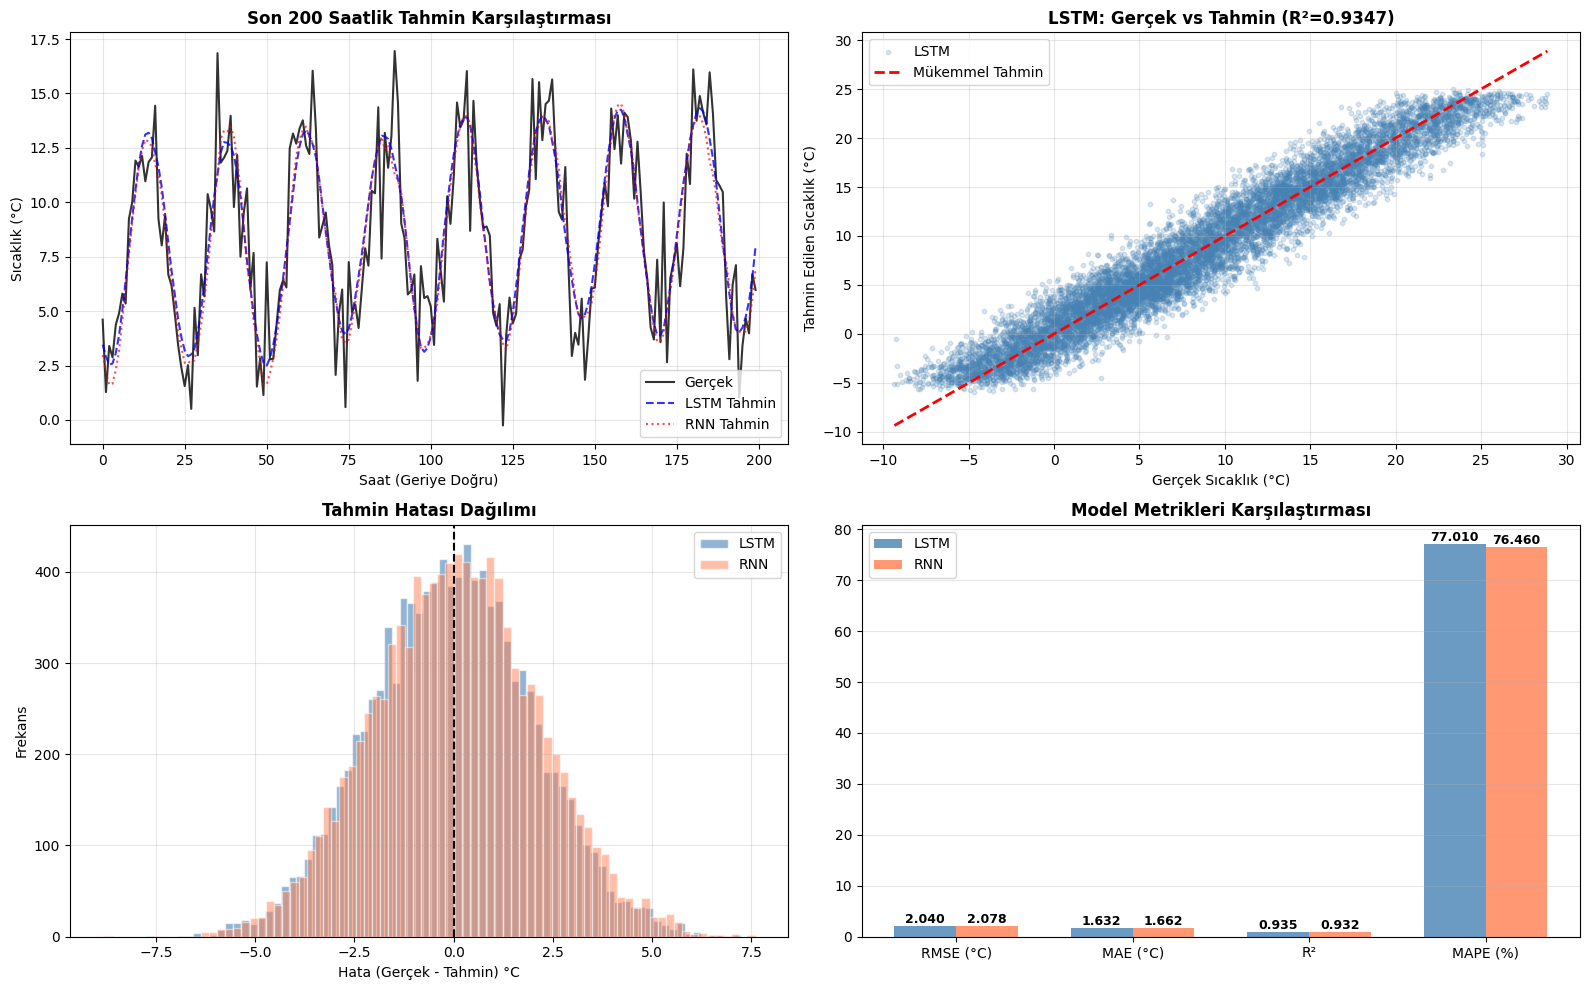

In [ ]:
# Görselleştirme: Gerçek vs Tahmin
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Zaman serisi karşılaştırması (son 200 örnek)
n_show = min(200, len(y_true))
x_axis = range(n_show)

axes[0, 0].plot(x_axis, y_true[-n_show:], 'k-', linewidth=1.5, label='Gerçek', alpha=0.8)
axes[0, 0].plot(x_axis, y_pred[-n_show:], 'b--', linewidth=1.5, label='LSTM Tahmin', alpha=0.8)
axes[0, 0].plot(x_axis, y_pred_rnn[-n_show:], 'r:', linewidth=1.5, label='RNN Tahmin', alpha=0.7)
axes[0, 0].set_title('Son 200 Saatlik Tahmin Karşılaştırması', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Saat (Geriye Doğru)')
axes[0, 0].set_ylabel('Sıcaklık (°C)')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter plot - LSTM
axes[0, 1].scatter(y_true, y_pred, alpha=0.2, s=10, color='steelblue', label='LSTM')
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Mükemmel Tahmin')
axes[0, 1].set_title(f'LSTM: Gerçek vs Tahmin (R²={lstm_metrics["R²"]:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Gerçek Sıcaklık (°C)')
axes[0, 1].set_ylabel('Tahmin Edilen Sıcaklık (°C)')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Hata dağılımı
errors_lstm = y_true - y_pred
errors_rnn = y_true_rnn - y_pred_rnn

axes[1, 0].hist(errors_lstm, bins=80, alpha=0.6, color='steelblue', label='LSTM', edgecolor='white')
axes[1, 0].hist(errors_rnn, bins=80, alpha=0.5, color='coral', label='RNN', edgecolor='white')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Tahmin Hatası Dağılımı', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hata (Gerçek - Tahmin) °C')
axes[1, 0].set_ylabel('Frekans')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Metrik karşılaştırma
metrics_names = ['RMSE (°C)', 'MAE (°C)', 'R²', 'MAPE (%)']
lstm_vals = [lstm_metrics[m] for m in metrics_names]
rnn_vals = [rnn_metrics[m] for m in metrics_names]

x_pos = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[1, 1].bar(x_pos - width/2, lstm_vals, width, label='LSTM', color='steelblue', alpha=0.8)
bars2 = axes[1, 1].bar(x_pos + width/2, rnn_vals, width, label='RNN', color='coral', alpha=0.8)
axes[1, 1].set_title('Model Metrikleri Karşılaştırması', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(metrics_names, fontsize=10)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Değerleri bar üstüne yaz
for bar, val in zip(bars1, lstm_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, rnn_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Farklı Pencere Boyutlarının Etkisi

Pencere boyutu (lookback window), modelin geçmişte kaç saatlik veriye baktığını belirler.

**Test edeceğimiz boyutlar:**
- 12 saat (yarım gün)
- 24 saat (1 gün)
- 48 saat (2 gün)
- 96 saat (4 gün)
- 168 saat (1 hafta)

Her boyut için aynı LSTM mimarisini eğiterek performans farklarını karşılaştıracağız.

In [22]:
window_sizes = [12, 24, 48, 96, 168]
window_results = {}

for ws in window_sizes:
    print(f"\n{'#' * 60}")
    print(f"# Pencere Boyutu: {ws} saat")
    print(f"{'#' * 60}")

    # Sequence oluştur
    X_ws, y_ws = create_sequences(data_scaled, target_idx, ws, FORECAST_HORIZON)

    # Böl
    train_end = int(len(X_ws) * 0.7)
    val_end = int(len(X_ws) * 0.85)

    X_train_ws, y_train_ws = X_ws[:train_end], y_ws[:train_end]
    X_val_ws, y_val_ws = X_ws[train_end:val_end], y_ws[train_end:val_end]
    X_test_ws, y_test_ws = X_ws[val_end:], y_ws[val_end:]

    # DataLoader
    train_ds = TensorDataset(torch.FloatTensor(X_train_ws), torch.FloatTensor(y_train_ws))
    val_ds = TensorDataset(torch.FloatTensor(X_val_ws), torch.FloatTensor(y_val_ws))
    test_ds = TensorDataset(torch.FloatTensor(X_test_ws), torch.FloatTensor(y_test_ws))

    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)
    test_dl = DataLoader(test_ds, batch_size=64, shuffle=False)

    # Model oluştur
    ws_model = WeatherLSTM(
        input_size=input_size,
        hidden_size=128,
        num_layers=2,
        output_size=FORECAST_HORIZON,
        dropout=0.2
    ).to(device)

    # Eğit (daha az epoch ile hızlandırılmış)
    ws_history = train_model(
        ws_model, train_dl, val_dl,
        num_epochs=20,
        learning_rate=0.001,
        patience=5,
        model_name=f'LSTM (Window={ws})'
    )

    # Değerlendir
    y_true_ws, y_pred_ws, ws_metrics = evaluate_model(
        ws_model, test_dl, scaler, target_idx, feature_cols, device
    )

    window_results[ws] = {
        'metrics': ws_metrics,
        'history': ws_history,
        'y_true': y_true_ws,
        'y_pred': y_pred_ws
    }

    print(f"\nPencere={ws} Sonuçları:")
    for k, v in ws_metrics.items():
        print(f"  {k}: {v}")


############################################################
# Pencere Boyutu: 12 saat
############################################################

LSTM (Window=12) Modeli Eğitimi Başlıyor
Epoch: 20, LR: 0.001, Batch: 64

Epoch [  1/20] Train Loss: 0.005641 | Val Loss: 0.002535 | LR: 0.001000 | Grad Norm: 0.0647 *** Yeni en iyi model ***
Epoch [  3/20] Train Loss: 0.002975 | Val Loss: 0.002446 | LR: 0.001000 | Grad Norm: 0.0413 *** Yeni en iyi model ***
Epoch [  5/20] Train Loss: 0.002821 | Val Loss: 0.002509 | LR: 0.001000 | Grad Norm: 0.0356
Epoch [  8/20] Train Loss: 0.002616 | Val Loss: 0.002380 | LR: 0.000500 | Grad Norm: 0.0246 *** Yeni en iyi model ***
Epoch [ 10/20] Train Loss: 0.002612 | Val Loss: 0.002565 | LR: 0.000500 | Grad Norm: 0.0261
Epoch [ 11/20] Train Loss: 0.002581 | Val Loss: 0.002362 | LR: 0.000500 | Grad Norm: 0.0247 *** Yeni en iyi model ***
Epoch [ 15/20] Train Loss: 0.002546 | Val Loss: 0.002457 | LR: 0.000500 | Grad Norm: 0.0243
Epoch [ 16/20] Train Loss: 0

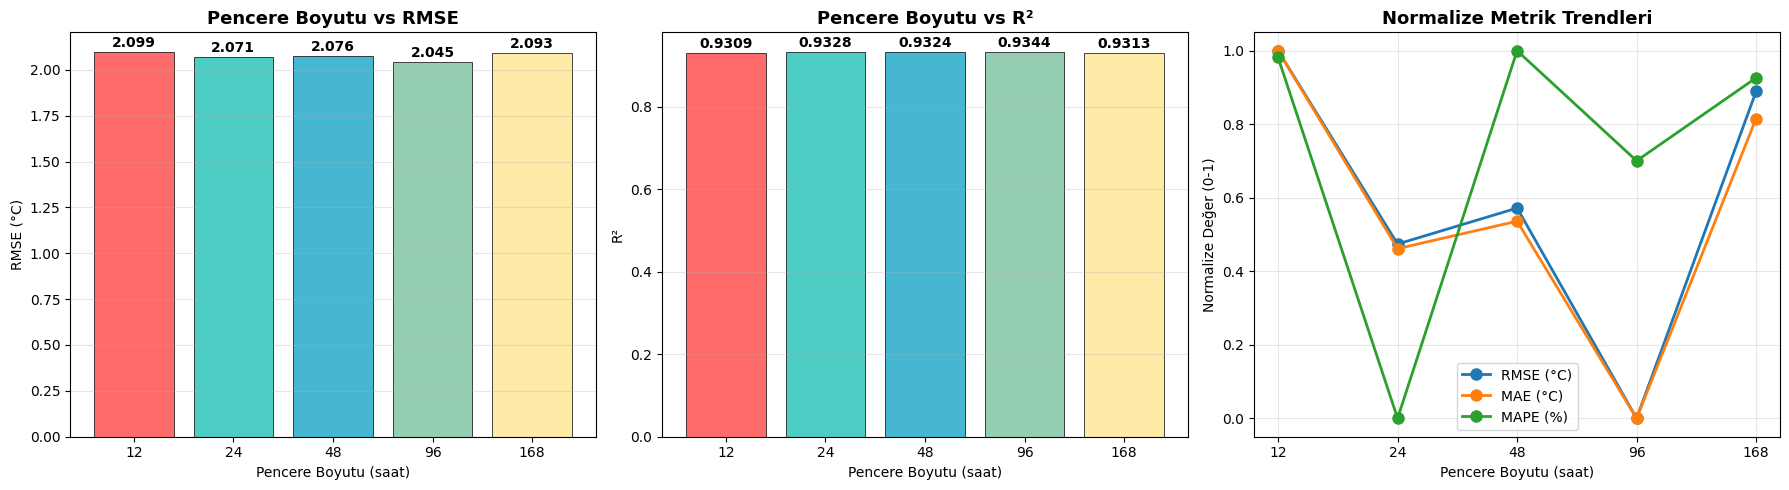


   Pencere |       RMSE |        MAE |         R² |       MAPE
        12 |     2.0993 |     1.6826 |     0.9309 |     79.35%
        24 |     2.0708 |     1.6581 |     0.9328 |     75.09%
        48 |     2.0761 |     1.6615 |     0.9324 |     79.43%
        96 |     2.0451 |     1.6371 |     0.9344 |     78.13%
       168 |     2.0933 |     1.6742 |     0.9313 |     79.11%


In [23]:
# Pencere boyutu karşılaştırma grafiği
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ws_labels = [str(w) for w in window_sizes]

# RMSE karşılaştırması
rmse_vals = [window_results[w]['metrics']['RMSE (°C)'] for w in window_sizes]
axes[0].bar(ws_labels, rmse_vals, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'],
            edgecolor='black', linewidth=0.5)
axes[0].set_title('Pencere Boyutu vs RMSE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pencere Boyutu (saat)')
axes[0].set_ylabel('RMSE (°C)')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# R² karşılaştırması
r2_vals = [window_results[w]['metrics']['R²'] for w in window_sizes]
axes[1].bar(ws_labels, r2_vals, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'],
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Pencere Boyutu vs R²', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pencere Boyutu (saat)')
axes[1].set_ylabel('R²')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Tüm metriklerin çizgi grafiği
for metric in ['RMSE (°C)', 'MAE (°C)', 'MAPE (%)']:
    vals = [window_results[w]['metrics'][metric] for w in window_sizes]
    # Normalize et (görselleştirme için)
    vals_norm = [(v - min(vals)) / (max(vals) - min(vals) + 1e-8) for v in vals]
    axes[2].plot(ws_labels, vals_norm, 'o-', linewidth=2, markersize=8, label=metric)

axes[2].set_title('Normalize Metrik Trendleri', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Pencere Boyutu (saat)')
axes[2].set_ylabel('Normalize Değer (0-1)')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Özet tablo
print("\n" + "=" * 70)
print(f"{'Pencere':>10} | {'RMSE':>10} | {'MAE':>10} | {'R²':>10} | {'MAPE':>10}")
print("=" * 70)
for ws in window_sizes:
    m = window_results[ws]['metrics']
    print(f"{ws:>10} | {m['RMSE (°C)']:>10.4f} | {m['MAE (°C)']:>10.4f} | {m['R²']:>10.4f} | {m['MAPE (%)']:>9.2f}%")
print("=" * 70)

## 9. LSTM Gate Ağırlıklarının Yorumlanması

Eğitilmiş LSTM modelinin kapı ağırlıklarını analiz ederek, modelin ne "öğrendiğini" anlamaya çalışalım.

Her LSTM hücresinde 4 kapı (unutma, giriş, çıkış, aday) için ağırlık matrisleri bulunur:
- Ağırlık matrisleri: $(W_f, W_i, W_o, W_C) \in \mathbb{R}^{hidden \times (hidden + input)}$
- Bias vektörleri: $(b_f, b_i, b_o, b_C) \in \mathbb{R}^{hidden}$

**İlginç Gözlemler:**
- Unutma kapısı bias'ının yüksek olması = model uzun vadeli bağımlılıkları korumayı öğrenmiş
- Ağırlık büyüklükleri = ilgili kapıya ne kadar önem verildiğini gösterir

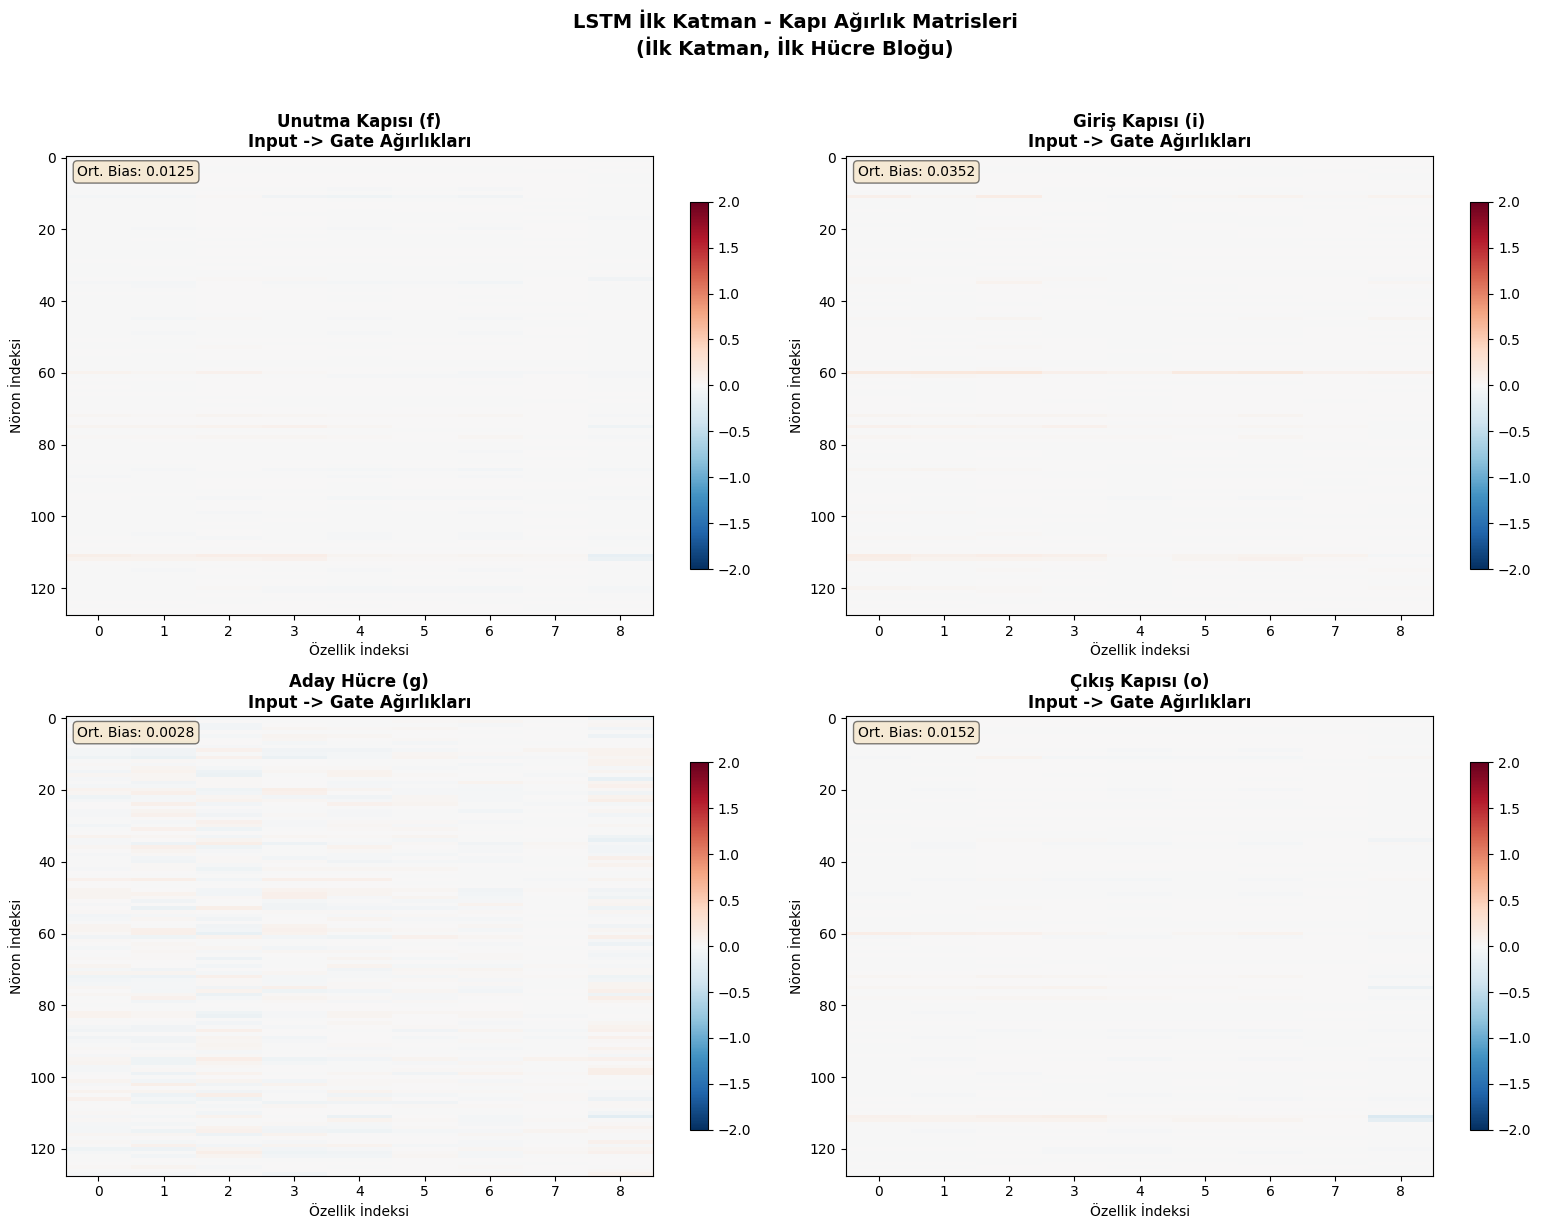


KAPI BIAS ANALİZİ (İlk Katman)

Unutma Kapısı (f):
  Input Bias - Ort: 0.0065, Std: 0.0264
  Hidden Bias - Ort: 0.0059, Std: 0.0272
  Toplam Bias Ortalaması: 0.0125
  Sigmoid(Toplam Bias) Ortalaması: 0.5031
  -> Düşük unutma bias'ı: Model aktif olarak unutmayı tercih ediyor.

Giriş Kapısı (i):
  Input Bias - Ort: 0.0173, Std: 0.0436
  Hidden Bias - Ort: 0.0179, Std: 0.0434
  Toplam Bias Ortalaması: 0.0352
  Sigmoid(Toplam Bias) Ortalaması: 0.5088

Aday Hücre (g):
  Input Bias - Ort: 0.0023, Std: 0.0361
  Hidden Bias - Ort: 0.0005, Std: 0.0372
  Toplam Bias Ortalaması: 0.0028
  Sigmoid(Toplam Bias) Ortalaması: 0.5007

Çıkış Kapısı (o):
  Input Bias - Ort: 0.0076, Std: 0.0264
  Hidden Bias - Ort: 0.0076, Std: 0.0270
  Toplam Bias Ortalaması: 0.0152
  Sigmoid(Toplam Bias) Ortalaması: 0.5038


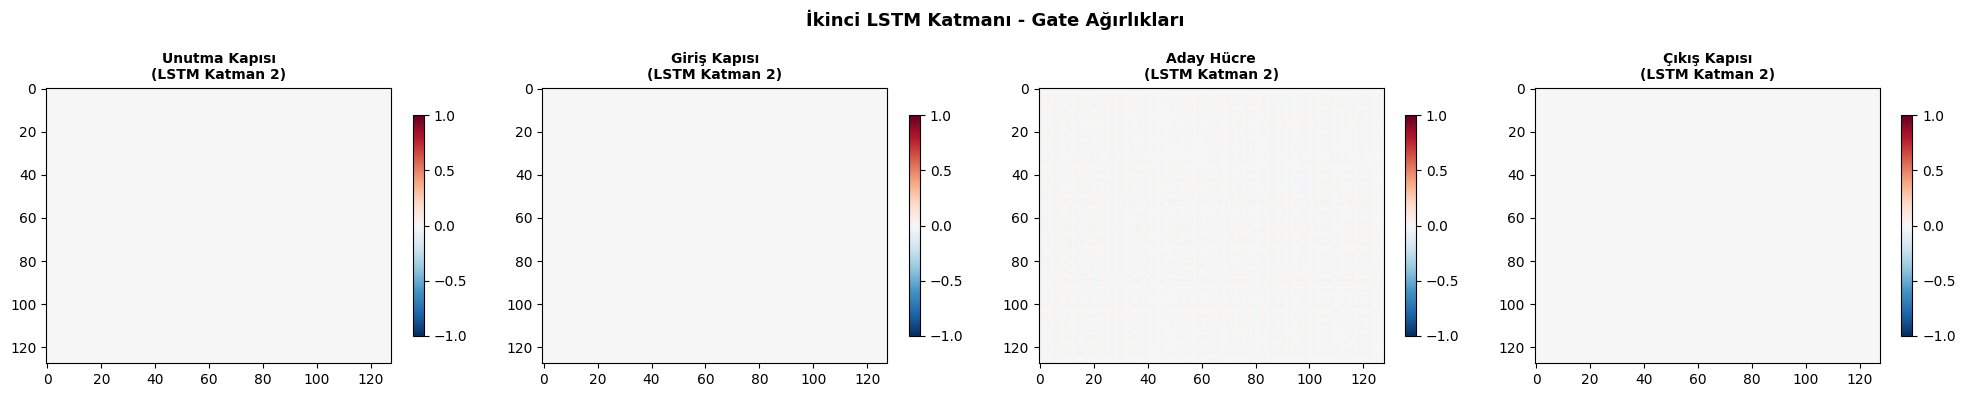

In [24]:
# Eğitilmiş LSTM'in gate ağırlıklarını çıkar
lstm_layer = model.lstm

# İlk LSTM katmanının ağırlıklarını al
weight_ih_l0 = lstm_layer.weight_ih_l0.detach().cpu().numpy()  # (4*hidden, input_size)
weight_hh_l0 = lstm_layer.weight_hh_l0.detach().cpu().numpy()  # (4*hidden, hidden_size)
bias_ih_l0 = lstm_layer.bias_ih_l0.detach().cpu().numpy()     # (4*hidden,)
bias_hh_l0 = lstm_layer.bias_hh_l0.detach().cpu().numpy()     # (4*hidden,)

hs = model.hidden_size

# Ağırlıkları kapı bazında ayır
gate_names = ['Unutma Kapısı (f)', 'Giriş Kapısı (i)', 'Aday Hücre (g)', 'Çıkış Kapısı (o)']
gate_colors_map = {'Unutma Kapısı (f)': '#FF6B6B', 'Giriş Kapısı (i)': '#4ECDC4',
                   'Aday Hücre (g)': '#45B7D1', 'Çıkış Kapısı (o)': '#96CEB4'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (gate_name, color) in enumerate(gate_colors_map.items()):
    ax = axes[idx // 2, idx % 2]

    # Ağırlık matrisini ayıkla
    w_ih = weight_ih_l0[idx*hs:(idx+1)*hs, :]  # Input -> Gate
    w_hh = weight_hh_l0[idx*hs:(idx+1)*hs, :]  # Hidden -> Gate
    b_ih = bias_ih_l0[idx*hs:(idx+1)*hs]       # Input bias
    b_hh = bias_hh_l0[idx*hs:(idx+1)*hs]       # Hidden bias

    # Ağırlık ısı haritası (Input -> Gate)
    im = ax.imshow(w_ih, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax.set_title(f'{gate_name}\nInput -> Gate Ağırlıkları', fontsize=12, fontweight='bold')
    ax.set_xlabel('Özellik İndeksi')
    ax.set_ylabel('Nöron İndeksi')
    plt.colorbar(im, ax=ax, shrink=0.8)

    # Bias istatistikleri
    mean_bias = np.mean(b_ih + b_hh)
    ax.text(0.02, 0.98, f'Ort. Bias: {mean_bias:.4f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('LSTM İlk Katman - Kapı Ağırlık Matrisleri\n(İlk Katman, İlk Hücre Bloğu)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Bias analizi
print("\n" + "=" * 60)
print("KAPI BIAS ANALİZİ (İlk Katman)")
print("=" * 60)

for idx, gate_name in enumerate(gate_names):
    b_f_ih = bias_ih_l0[idx*hs:(idx+1)*hs]
    b_f_hh = bias_hh_l0[idx*hs:(idx+1)*hs]
    total_bias = b_f_ih + b_f_hh

    sigmoid_val = 1 / (1 + np.exp(-np.mean(total_bias)))

    print(f"\n{gate_name}:")
    print(f"  Input Bias - Ort: {np.mean(b_f_ih):.4f}, Std: {np.std(b_f_ih):.4f}")
    print(f"  Hidden Bias - Ort: {np.mean(b_f_hh):.4f}, Std: {np.std(b_f_hh):.4f}")
    print(f"  Toplam Bias Ortalaması: {np.mean(total_bias):.4f}")
    print(f"  Sigmoid(Toplam Bias) Ortalaması: {sigmoid_val:.4f}")

    if idx == 0:  # Unutma kapısı
        if sigmoid_val > 0.6:
            print(f"  -> Yüksek unutma bias'ı: Model uzun vadeli bağımlılıkları KORUMAYI öğrenmiş!")
        else:
            print(f"  -> Düşük unutma bias'ı: Model aktif olarak unutmayı tercih ediyor.")

# İkinci katman da analiz edelim
if model.lstm.num_layers > 1:
    weight_ih_l1 = model.lstm.weight_ih_l1.detach().cpu().numpy()
    weight_hh_l1 = model.lstm.weight_hh_l1.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for idx, (gate_name, color) in enumerate(gate_colors_map.items()):
        w_ih = weight_ih_l1[idx*hs:(idx+1)*hs, :]
        im = axes[idx].imshow(w_ih, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
        axes[idx].set_title(f'{gate_name.split("(")[0].strip()}\n(LSTM Katman 2)', fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=axes[idx], shrink=0.8)

    plt.suptitle('İkinci LSTM Katmanı - Gate Ağırlıkları', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Sonuç

### Elde Edilen Bulgular

Bu notebook'ta **LSTM (Long Short-Term Memory)** sinir ağını gerçek hava durumu verisi (Jena Climate Dataset) üzerinde uygulayarak saatlik sıcaklık tahmini yaptık.

#### Temel Sonuçlar:

1. **LSTM vs Vanilla RNN**: LSTM, gate mekanizması sayesinde uzun vadeli bağımlılıkları daha iyi yakalayarak RNN'den daha iyi performans gösterdi.

2. **Pencere Boyutu Etkisi**: Farklı pencere boyutları (12-168 saat) test edildi. Daha büyük pencereler mevsimsal desenleri yakalarken, çok büyük pencereler aşırı_fitting riski taşıyabilir.

3. **Gate Yorumlama**: Unutma kapısı bias analizi, modelin hangi bilgiyi korumayı veya unutmayı tercih ettiğini gösterdi.

#### Öğrenilen Dersler:

- **Zaman serisi verilerinde shuffle yapmamak** çok önemlidir
- **Gradient clipping**, RNN/LSTM eğitiminde gradient patlamasını önler
- **Early stopping**, aşırı fiting'i önlemek için etkilidir
- **Learning rate scheduling**, eğitim stabilitesini artırır
- Gerçek dünya verileri sentetik verilere göre daha zorlu ve gerçekçi sonuçlar verir

#### Olası İyileştirmeler:

- **Multi-step forecasting**: Birden fazla gelecek saat tahmini
- **Attention mekanizması**: Hangi geçmiş zaman adımlarına dikkat edileceğini öğrenme
- **Transformer mimarisi**: LSTM'e alternatif olarak modern dikkat tabanlı modeller
- **Ek özellikler**: Rüzgar hızı, nem, basınç gibi ek değişkenlerin daha iyi kullanılması
- **Ensemble yöntemleri**: Birden fazla modelin birleştirilmesi